# COMP4680/8650 – Flow Matching Assignment

| Part | Topic | Marks |
|------|-------|-------|
| 1 | Warm-up | 10 |
| 2 | Flow Matching Parameterization | 34 |
| 3 | Can We Rescue v-Prediction? | 25 |
| 4 | One-Step Generation (MeanFlow) | 31 |
| | **Total** | **100** |

In [1]:
import os, sys, math
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm import tqdm

os.makedirs('figures', exist_ok=True)
os.makedirs('models', exist_ok=True)

sys.path.insert(0, str(Path().resolve()))
from src.dataloader import ToyDiffusionDataset, get_dataloader

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', DEVICE)

Using device: cuda


---
## Part 1 – Warm-up (10 marks)

### 1.1 Data Visualization (3 marks)

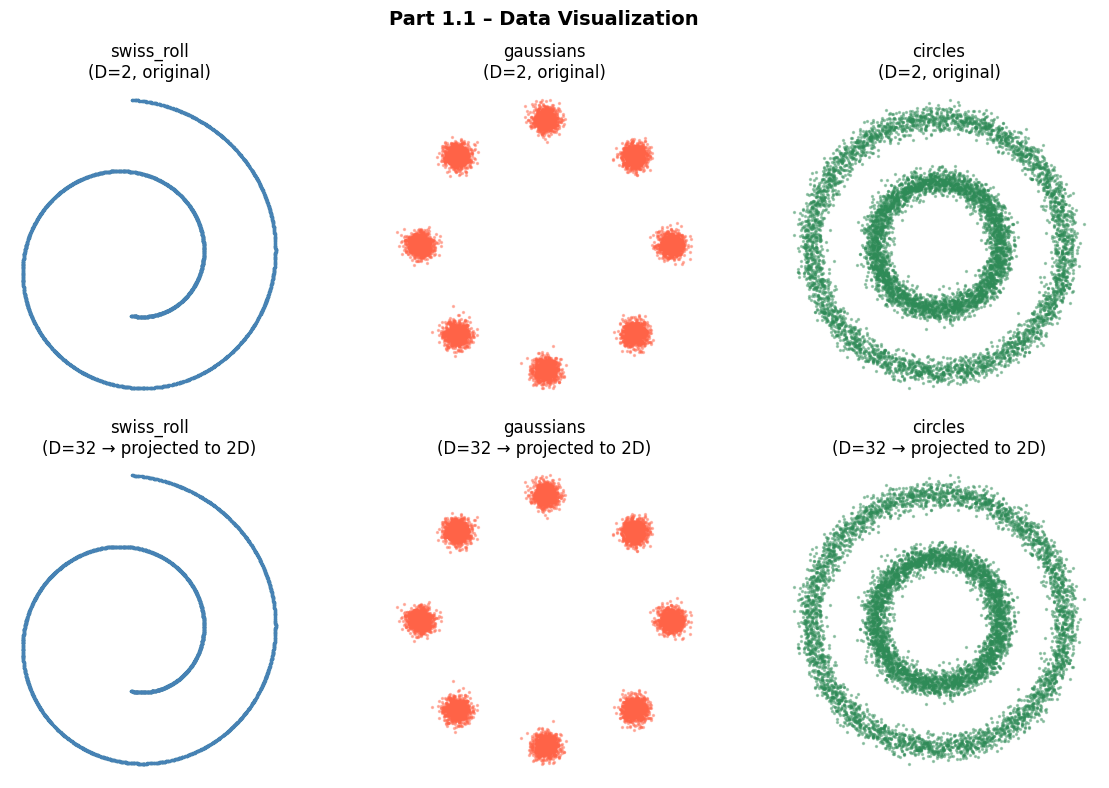

In [2]:
DATASETS = ['swiss_roll', 'gaussians', 'circles']
COLORS   = {'swiss_roll': 'steelblue', 'gaussians': 'tomato', 'circles': 'seagreen'}

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
fig.suptitle('Part 1.1 – Data Visualization', fontsize=14, fontweight='bold')

for col, name in enumerate(DATASETS):
    ds2 = ToyDiffusionDataset(name=name, dim=2)
    data2 = ds2.data.numpy()
    ax = axes[0, col]
    ax.scatter(data2[:, 0], data2[:, 1], s=2, alpha=0.4, color=COLORS[name])
    ax.set_title(f'{name}\n(D=2, original)')
    ax.set_aspect('equal'); ax.axis('off')

    ds32 = ToyDiffusionDataset(name=name, dim=32)
    data32_2d = ds32.to_2d(ds32.data.numpy())
    ax = axes[1, col]
    ax.scatter(data32_2d[:, 0], data32_2d[:, 1], s=2, alpha=0.4, color=COLORS[name])
    ax.set_title(f'{name}\n(D=32 → projected to 2D)')
    ax.set_aspect('equal'); ax.axis('off')

axes[0, 0].set_ylabel('D=2 original', fontsize=10)
axes[1, 0].set_ylabel('D=32 projected', fontsize=10)
plt.tight_layout()
plt.savefig('report/figures/part1_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

### Flow Conversion Helpers

**Linear interpolant** and **ground-truth velocity:**

$$z_t = (1 - t)\,x + t\,\varepsilon, \qquad v = \varepsilon - x$$

**All conversions** (derived by rearranging the two equations above):

| From | To | Formula |
|------|----|---------|
| $v$ | $x$ | $x = z_t - t \cdot v$ |
| $x$ | $v$ | $v = (z_t - x)\,/\,t$ |
| $v$ | $\varepsilon$ | $\varepsilon = z_t + (1-t) \cdot v$ |
| $x$ | $\varepsilon$ | $\varepsilon = \bigl(z_t - (1-t)\,x\bigr)\,/\,t$ |

In [3]:
# ── Flow conversion helpers ──────────────────────────────────────────────────

def _te(t):
    """Expand t (B,) to (B, 1) for broadcasting."""
    return t.unsqueeze(-1)

def lin_interpolation(x, eps, t):
    """z_t = (1 - t) * x + t * eps"""
    return (1 - _te(t)) * x + _te(t) * eps

def gt_velocity(x, eps):
    """Ground-truth velocity: v = eps - x"""
    return eps - x

def v_to_x(v, z_t, t):
    """v-pred → x:  x = z_t - t * v"""
    return z_t - _te(t) * v

def x_to_v(x, z_t, t):
    """x-pred → v:  v = (z_t - x) / t"""
    return (z_t - x) / _te(t).clamp(min=1e-8)

def v_to_eps(v, z_t, t):
    """v-pred → eps:  eps = z_t + (1 - t) * v"""
    return z_t + (1 - _te(t)) * v

def x_to_eps(x, z_t, t):
    """x-pred → eps:  eps = (z_t - (1 - t) * x) / t"""
    return (z_t - (1 - _te(t)) * x) / _te(t).clamp(min=1e-8)

print('Flow conversion helpers defined.')


Flow conversion helpers defined.


### 1.2 v-Prediction Flow Matching at D=2 (7 marks)

#### Model Architecture

In [14]:
class SinusoidalEmbedding(nn.Module):
    """Map scalar t -> 128-dim sinusoidal embedding (DiT-style)."""
    def __init__(self, dim=128):
        super().__init__()
        self.dim = dim
        k = dim // 2
        i = torch.arange(k, dtype=torch.float32)
        freqs = torch.exp(-i * (torch.log(torch.tensor(10000.0)) / (k - 1)))
        self.register_buffer('freqs', freqs)

    def forward(self, t):
        t = t.float().unsqueeze(-1)
        args = t * self.freqs.unsqueeze(0)
        return torch.cat([torch.sin(args), torch.cos(args)], dim=-1)  # (B, 128)


class FlowMLP(nn.Module):
    """5-layer MLP denoiser (Parts 1–3). Predicts x or v depending on use."""
    def __init__(self, data_dim: int, hidden=256, time_dim=128):
        super().__init__()
        self.time_embed = SinusoidalEmbedding(time_dim)
        in_dim = data_dim + time_dim
        layers = [nn.Linear(in_dim, hidden), nn.ReLU()]
        for _ in range(4):
            layers += [nn.Linear(hidden, hidden), nn.ReLU()]
        layers.append(nn.Linear(hidden, data_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, z, t):
        e = self.time_embed(t)
        return self.net(torch.cat([z, e], dim=-1))


print('FlowMLP defined.')

FlowMLP defined.


#### Training Loop

In [ ]:
def train_flow_matching(
    dataset_name, dim=2, n_steps=25000, batch_size=1024, lr=1e-4,
    pred_type='v', loss_type='v', eps_clip=1e-2, device=DEVICE,
    hidden=256,
):
    loader = get_dataloader(name=dataset_name, dim=dim, batch_size=batch_size)
    data_iter = iter(loader)
    model = FlowMLP(data_dim=dim, hidden=hidden).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []
    model.train()

    for step in tqdm(range(n_steps), desc=f'{dataset_name} D={dim} {pred_type}/{loss_type}', leave=False):
        try:
            x = next(data_iter).to(device).float()
        except StopIteration:
            data_iter = iter(loader)
            x = next(data_iter).to(device).float()

        B = x.shape[0]
        noise = torch.randn_like(x)
        t     = torch.rand(B, device=device).clamp(eps_clip, 1 - eps_clip)
        z_t   = lin_interpolation(x, noise, t)
        v_gt  = gt_velocity(x, noise)

        pred = model(z_t, t)

        if pred_type == 'v' and loss_type == 'v':
            loss = nn.functional.mse_loss(pred, v_gt)
        elif pred_type == 'v' and loss_type == 'x':
            loss = nn.functional.mse_loss(v_to_x(pred, z_t, t), x)
        elif pred_type == 'x' and loss_type == 'x':
            loss = nn.functional.mse_loss(pred, x)
        elif pred_type == 'x' and loss_type == 'v':
            loss = nn.functional.mse_loss(x_to_v(pred, z_t, t), v_gt)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if step % 1000 == 0:
            losses.append(loss.item())

    return model, losses


@torch.no_grad()
def euler_sample(model, n_samples, dim, n_euler_steps=50, pred_type='v', device=DEVICE):
    """Euler ODE sampling: t=1 (noise) -> t=0 (data)."""
    model.eval()
    z  = torch.randn(n_samples, dim, device=device)
    ts = torch.linspace(1.0, 0.0, n_euler_steps + 1, device=device)[:-1]
    dt = -1.0 / n_euler_steps
    for t_val in ts:
        t    = t_val.expand(n_samples)
        pred = model(z, t)
        v    = x_to_v(pred, z, t) if pred_type == 'x' else pred
        z    = z + v * dt
    return z.cpu().numpy()


print('Training and sampling functions defined.')

Training and sampling functions defined.


#### Train & Visualize (Part 1.2)

In [6]:
models_part1 = {}
for name in DATASETS:
    model, losses = train_flow_matching(dataset_name=name, dim=2, pred_type='v', loss_type='v')
    models_part1[name] = model
    print(f'{name}: final loss = {losses[-1]:.4f}')

swiss_roll: final loss = 0.9602


gaussians: final loss = 0.8908


circles: final loss = 0.8588


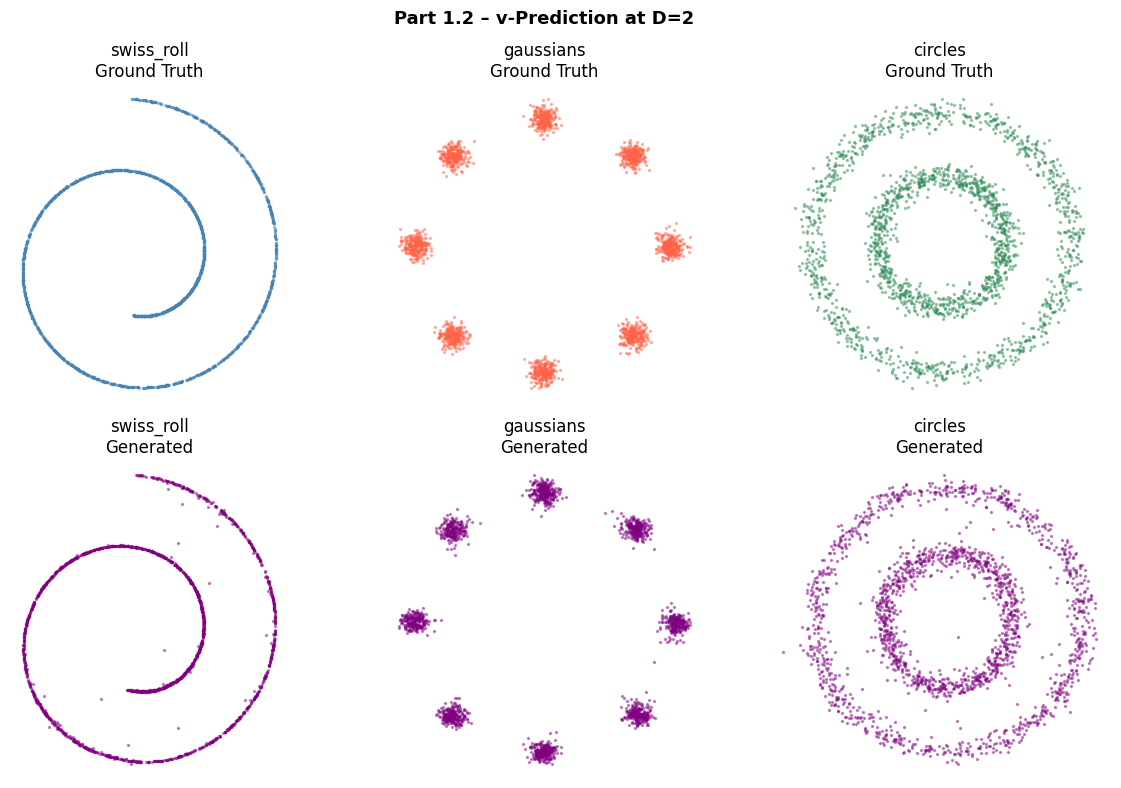

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
fig.suptitle('Part 1.2 – v-Prediction at D=2', fontsize=13, fontweight='bold')

for col, name in enumerate(DATASETS):
    ds = ToyDiffusionDataset(name=name, dim=2)
    gt = ds.data.numpy()
    samples = euler_sample(models_part1[name], n_samples=2000, dim=2, pred_type='v')

    axes[0, col].scatter(gt[:2000, 0], gt[:2000, 1], s=2, alpha=0.4, color=COLORS[name])
    axes[0, col].set_title(f'{name}\nGround Truth')
    axes[0, col].set_aspect('equal'); axes[0, col].axis('off')

    axes[1, col].scatter(samples[:, 0], samples[:, 1], s=2, alpha=0.4, color='purple')
    axes[1, col].set_title(f'{name}\nGenerated')
    axes[1, col].set_aspect('equal'); axes[1, col].axis('off')

plt.tight_layout()
plt.savefig('report/figures/part1_generated.png', dpi=150, bbox_inches='tight')
plt.show()

**Hyperparameters used:**
- Model: 5-layer MLP, 256 hidden units, DiT-style timestep embedding (128-dim sinusoidal + MLP → 256-dim)
- Training: 25,000 steps, batch size 1024, lr=1e-3, Adam optimizer
- Sampling: 50-step Euler ODE, 2000 samples

---
## Part 2 – Flow Matching Parameterization (34 marks)

### 2.1 Derivation: x ↔ v conversions

From the linear interpolant $z_t = (1-t)x + t\\epsilon$, the velocity field is $v = \\dot{z}_t = \\epsilon - x$.

- **v → x:** $x = z_t - t \\cdot v$
- **x → v:** $v = (z_t - x) / t$

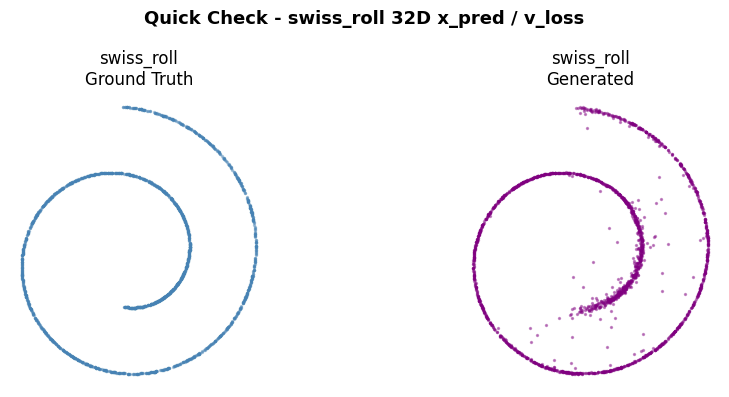

In [38]:
# Quick Sanity Check: 

_dataset = 'swiss_roll' # Options: 'swiss_roll', 'gaussians', 'circles'
_dim = 32 # Options: 2, 8, 32
_pred_type = 'x'
_loss_type = 'v'

_n_steps = 25000
_batch_size = 1024
_lr = 1e-4
_eps_clip = 1e-2
_hidden = 256

# Train
model, losses = train_flow_matching(
    dataset_name=_dataset, dim=_dim, n_steps=_n_steps, batch_size=_batch_size, lr=_lr,
    pred_type=_pred_type, loss_type=_loss_type, eps_clip=_eps_clip, device=DEVICE,
    hidden=_hidden)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle(f'Quick Check - {_dataset} {_dim}D {_pred_type}_pred / {_loss_type}_loss', fontsize=13, fontweight='bold')

ds = ToyDiffusionDataset(name=_dataset, dim=_dim)
gt = ds.to_2d(ds.data.numpy())
samples = euler_sample(model, n_samples=2000, dim=_dim, pred_type=_pred_type)
samples_2d = ds.to_2d(samples)

axes[0].scatter(gt[:2000, 0], gt[:2000, 1], s=2, alpha=0.4, color=COLORS[_dataset])
axes[0].set_title(f'{_dataset}\nGround Truth')
axes[0].set_aspect('equal'); axes[0].axis('off')

axes[1].scatter(samples_2d[:, 0], samples_2d[:, 1], s=2, alpha=0.4, color='purple')
axes[1].set_title(f'{_dataset}\nGenerated')
axes[1].set_aspect('equal'); axes[1].axis('off')

plt.tight_layout()
plt.show()

In [9]:
COMBOS = [('v','v'), ('v','x'), ('x','x'), ('x','v')]
DIMS   = [2, 8, 32]
print(f'Total experiments: {len(COMBOS) * len(DIMS) * len(DATASETS)} (4 combos × 3 dims × 3 datasets)')

Total experiments: 36 (4 combos × 3 dims × 3 datasets)


In [10]:
# Train all 36 combinations
results_p2 = {}

for name in DATASETS:
    for dim in DIMS:
        for pred_type, loss_type in COMBOS:
            key = (name, dim, pred_type, loss_type)
            save_path = f'models/{name}_D{dim}_{pred_type}pred_{loss_type}loss.pt'
            model, _ = train_flow_matching(
                dataset_name=name, dim=dim,
                pred_type=pred_type, loss_type=loss_type,
                n_steps=25000
            )
            results_p2[key] = model
            torch.save(model.state_dict(), save_path)

print('All 36 models trained and saved.')

All 36 models trained and saved.


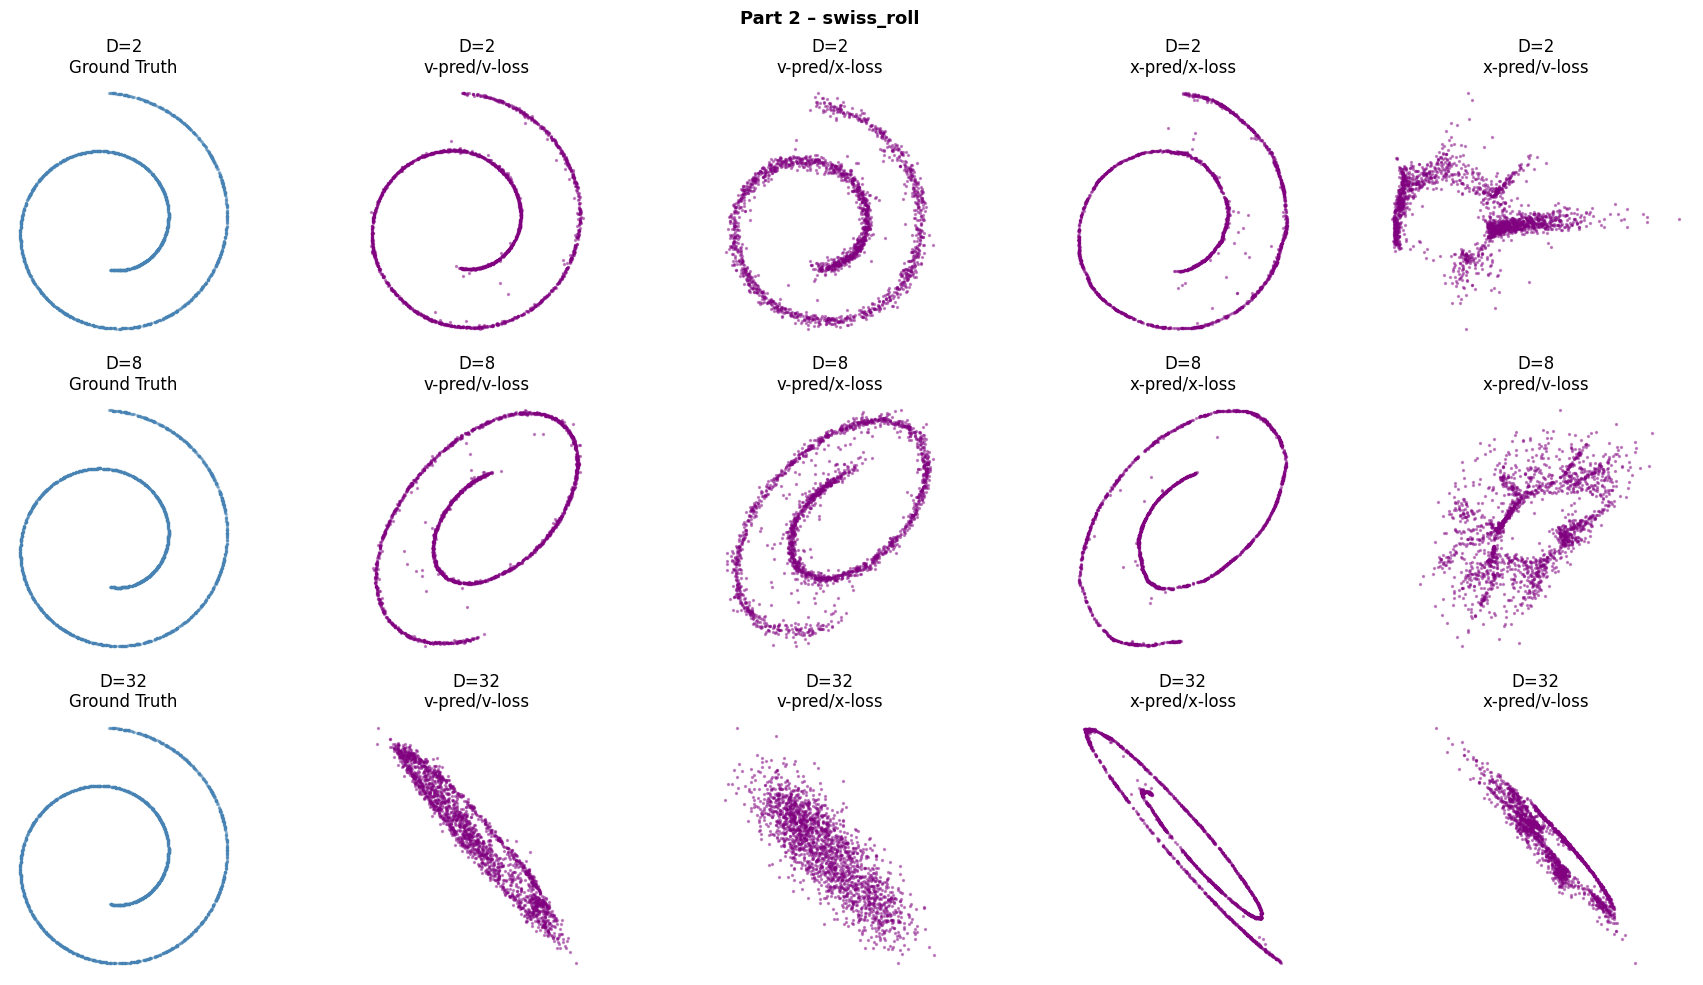

Saved: report/figures/part2_swiss_roll.png


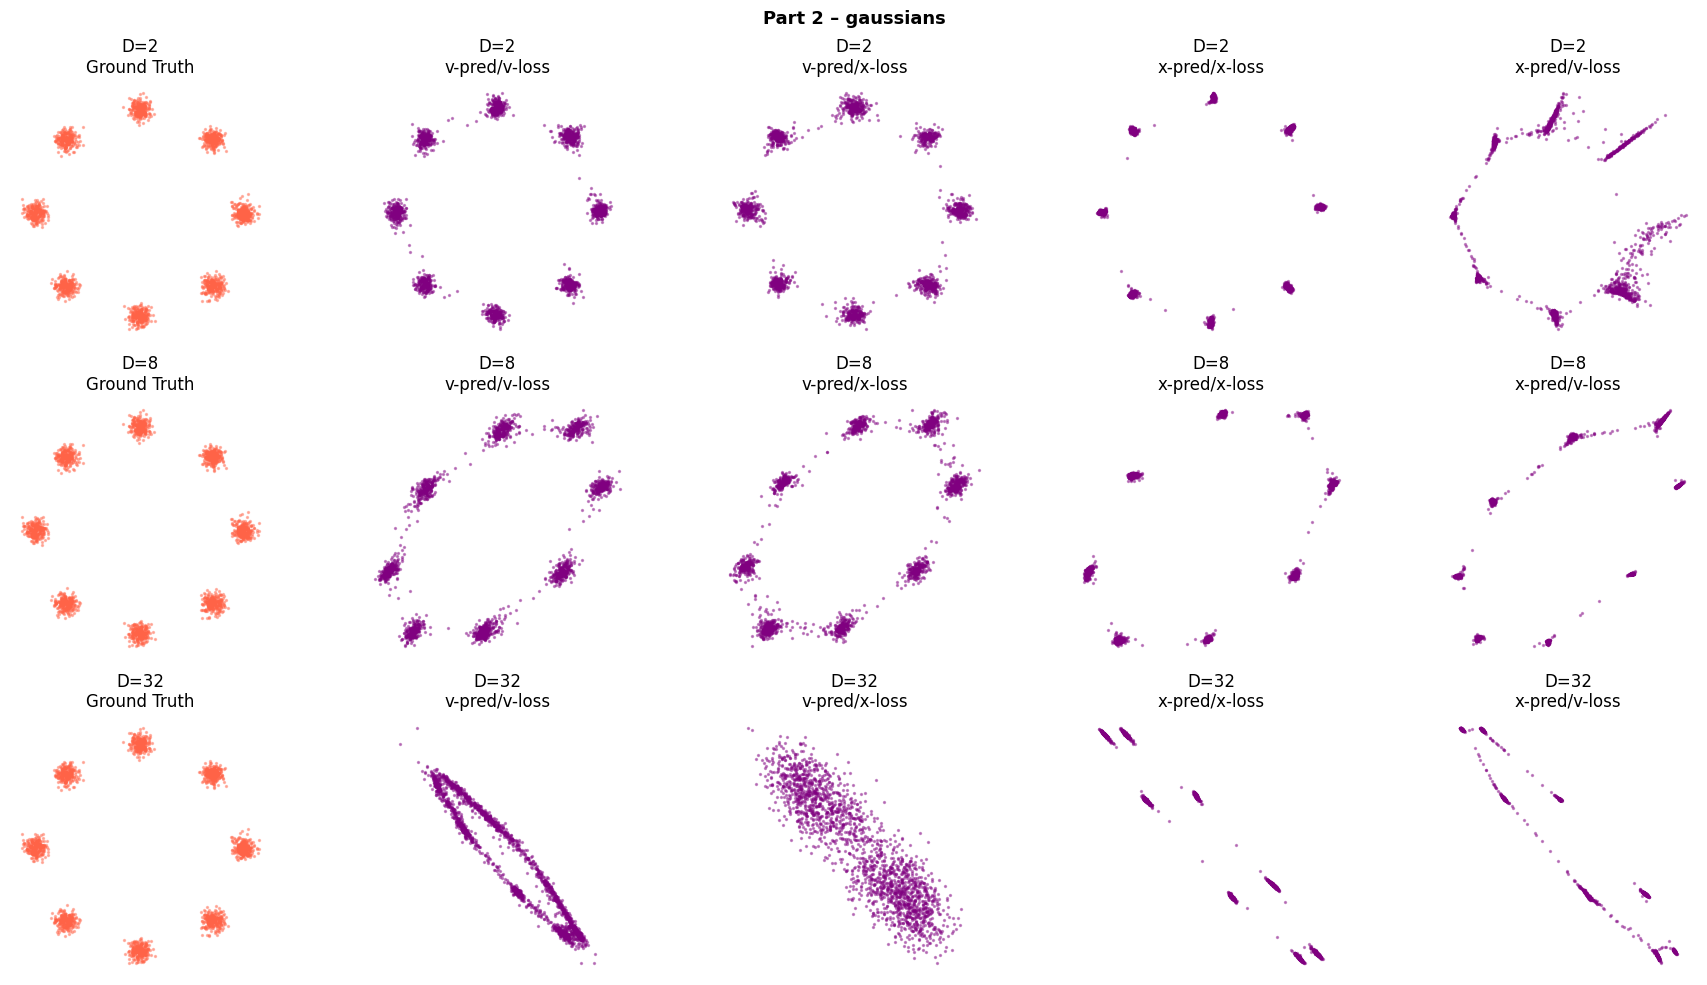

Saved: report/figures/part2_gaussians.png


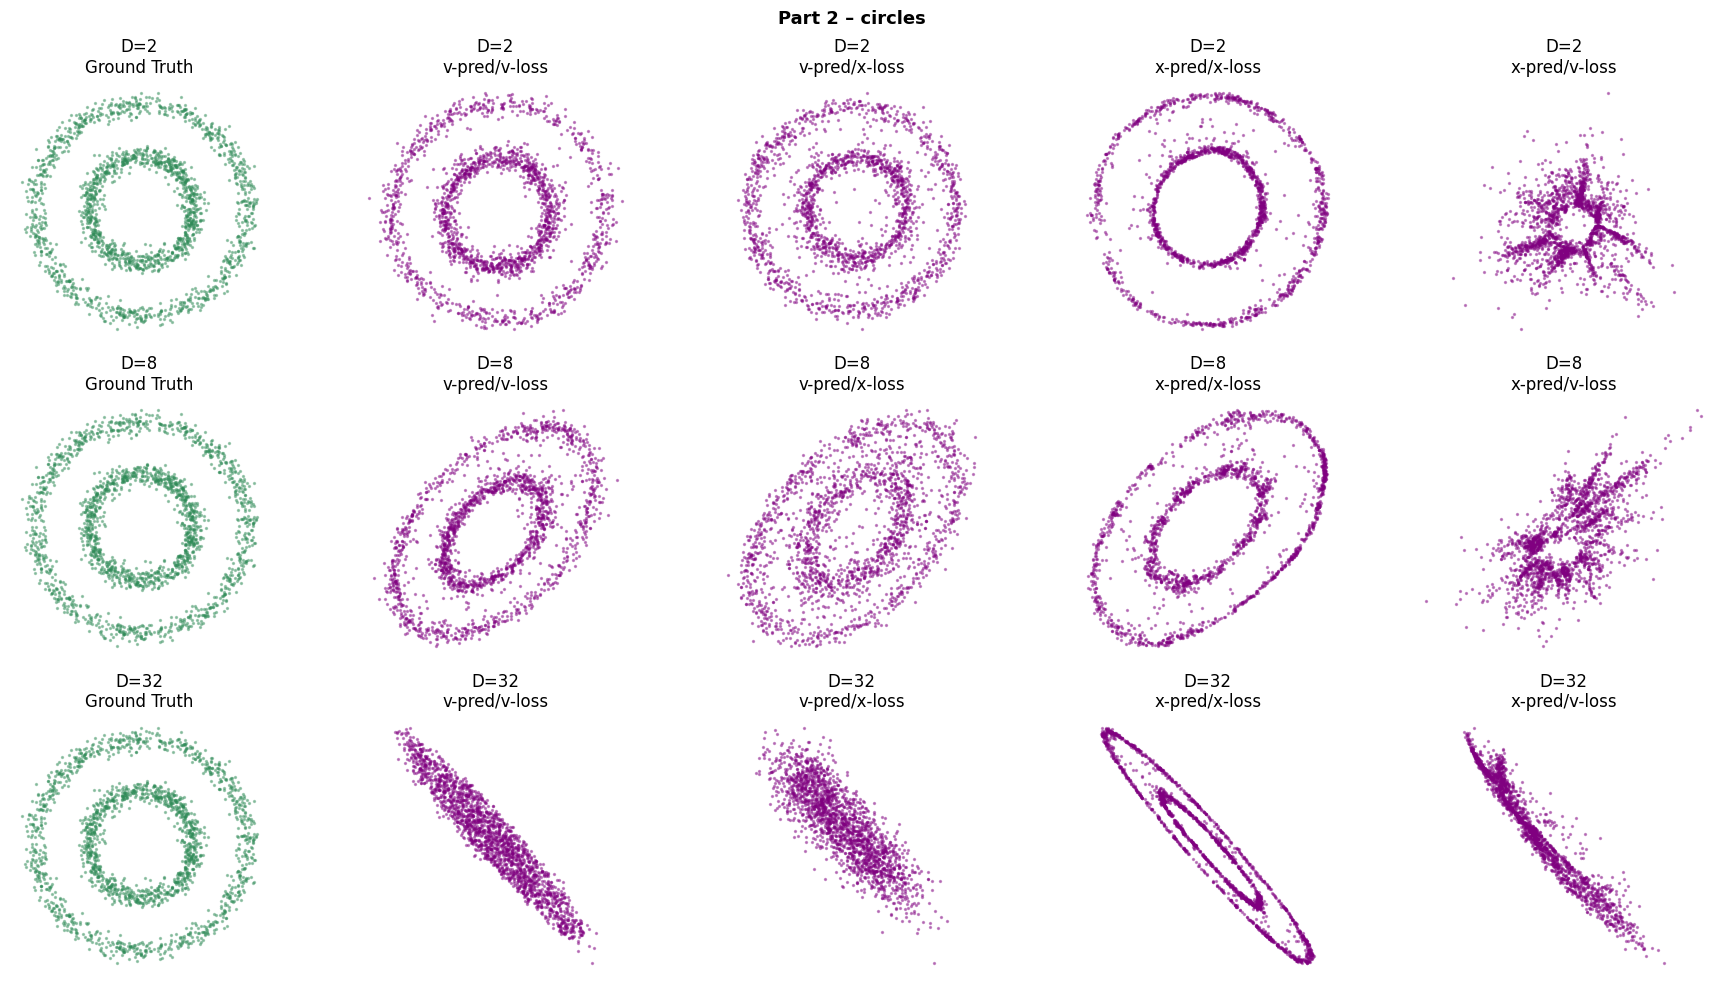

Saved: report/figures/part2_circles.png


In [11]:
for name in DATASETS:
    fig, axes = plt.subplots(len(DIMS), len(COMBOS) + 1, figsize=(18, 10))
    fig.suptitle(f'Part 2 – {name}', fontsize=13, fontweight='bold')

    for row, dim in enumerate(DIMS):
        ds = ToyDiffusionDataset(name=name, dim=dim)
        gt_2d = ds.to_2d(ds.data.numpy())

        axes[row, 0].scatter(gt_2d[:2000, 0], gt_2d[:2000, 1], s=2, alpha=0.4, color=COLORS[name])
        axes[row, 0].set_title(f'D={dim}\nGround Truth')
        axes[row, 0].set_aspect('equal'); axes[row, 0].axis('off')

        for col, (pred_type, loss_type) in enumerate(COMBOS):
            save_path = f'models/{name}_D{dim}_{pred_type}pred_{loss_type}loss.pt'
            model = FlowMLP(data_dim=dim).to(DEVICE)
            model.load_state_dict(torch.load(save_path, map_location=DEVICE))
            model.eval()

            samples = euler_sample(model, n_samples=2000, dim=dim, pred_type=pred_type)

            axes[row, col+1].scatter(samples[:, 0], samples[:, 1], s=2, alpha=0.4, color='purple')
            axes[row, col+1].set_title(f'D={dim}\n{pred_type}-pred/{loss_type}-loss')
            axes[row, col+1].set_aspect('equal'); axes[row, col+1].axis('off')

    plt.tight_layout()
    plt.savefig(f'report/figures/part2_{name}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: report/figures/part2_{name}.png')

### 2.2 Questions

**Q1.** Which prediction type scales successfully to high ambient dimensions?

> *[Fill in your answer here]*

**Q2.** Why does v-prediction fail at high dimensions?

> *[Fill in your answer here]*

**Q3.** Does the loss type matter independently of the prediction type?

> *[Fill in your answer here]*

---
## Part 3 – Can We Rescue v-Prediction? (25 marks)

From Part 2, v-prediction fails at $D \\geq 8$. In this part we investigate whether this failure is fundamental
or can be overcome with simple modifications.

In [12]:
def train_v_scaled(
    dataset_name, dim=32, n_steps=25000, batch_size=1024,
    lr=1e-3, eps_clip=1e-4, hidden=256, scale_factor=None, device=DEVICE
):
    """
    v-prediction with optional target scaling.
    scale_factor: if None, use 1/sqrt(dim); if 1.0, no scaling (baseline).
    """
    if scale_factor is None:
        scale_factor = 1.0 / (dim ** 0.5)

    loader = get_dataloader(name=dataset_name, dim=dim, batch_size=batch_size)
    data_iter = iter(loader)
    model = FlowMLP(data_dim=dim, hidden=hidden).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []
    model.train()

    for step in tqdm(range(n_steps), desc=f'{dataset_name} D={dim} v-scaled h={hidden}', leave=False):
        try:
            x = next(data_iter).to(device).float()
        except StopIteration:
            data_iter = iter(loader)
            x = next(data_iter).to(device).float()

        B = x.shape[0]
        noise = torch.randn_like(x)
        t     = torch.rand(B, device=device).clamp(eps_clip, 1 - eps_clip)
        z_t   = noisy_sample(x, noise, t)
        v_gt  = gt_velocity(x, noise)

        pred = model(z_t, t)
        loss = nn.functional.mse_loss(pred * scale_factor, v_gt * scale_factor)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if step % 1000 == 0:
            losses.append(loss.item())

    return model, losses


@torch.no_grad()
def euler_sample_v(model, n_samples, dim, n_euler_steps=50, device=DEVICE):
    """Euler ODE for v-prediction model."""
    return euler_sample(model, n_samples, dim, n_euler_steps, pred_type='v', device=device)


print('Part 3 training functions defined.')

Part 3 training functions defined.


In [13]:
p3_configs = {
    'x-pred (baseline)':    dict(pred_type='x', loss_type='x', hidden=256, n_steps=25000),
    'v-pred (default)':     dict(pred_type='v', loss_type='v', hidden=256, n_steps=25000),
}
p3_models = {}
DIM_P3    = 32

for label, cfg in p3_configs.items():
    model, _ = train_flow_matching(
        dataset_name='swiss_roll', dim=DIM_P3,
        pred_type=cfg['pred_type'], loss_type=cfg['loss_type'],
        hidden=cfg['hidden'], n_steps=cfg['n_steps']
    )
    p3_models[label] = model
    print(f'Trained: {label}')

model_scaled, _ = train_v_scaled(
    dataset_name='swiss_roll', dim=DIM_P3, n_steps=25000, scale_factor=None
)
p3_models['v-pred (scaled 1/√D)'] = model_scaled
print('Trained: v-pred (scaled 1/√D)')

model_large, _ = train_flow_matching(
    dataset_name='swiss_roll', dim=DIM_P3, pred_type='v', loss_type='v', hidden=512, n_steps=25000
)
p3_models['v-pred (512 hidden)'] = model_large
print('Trained: v-pred (512 hidden)')

model_moresteps, _ = train_flow_matching(
    dataset_name='swiss_roll', dim=DIM_P3, pred_type='v', loss_type='v', hidden=256, n_steps=100000
)
p3_models['v-pred (100K steps)'] = model_moresteps
print('Trained: v-pred (100K steps)')

Trained: x-pred (baseline)


Trained: v-pred (default)


NameError: name 'noisy_sample' is not defined

In [ ]:
ds_p3 = ToyDiffusionDataset(name='swiss_roll', dim=DIM_P3)
gt_2d = ds_p3.to_2d(ds_p3.data.numpy())

n_configs = len(p3_models)
fig, axes = plt.subplots(1, n_configs + 1, figsize=(4 * (n_configs + 1), 4))
fig.suptitle(f'Part 3 – Rescuing v-Prediction (swiss_roll, D={DIM_P3})', fontsize=12, fontweight='bold')

axes[0].scatter(gt_2d[:2000, 0], gt_2d[:2000, 1], s=2, alpha=0.4, color='steelblue')
axes[0].set_title('Ground Truth')
axes[0].set_aspect('equal'); axes[0].axis('off')

for i, (label, model) in enumerate(p3_models.items()):
    pt = 'x' if 'x-pred' in label else 'v'
    samples = euler_sample(model, n_samples=2000, dim=DIM_P3, pred_type=pt)
    samples_2d = ds_p3.to_2d(samples)
    axes[i + 1].scatter(samples_2d[:, 0], samples_2d[:, 1], s=2, alpha=0.4, color='purple')
    axes[i + 1].set_title(label, fontsize=9)
    axes[i + 1].set_aspect('equal'); axes[i + 1].axis('off')

plt.tight_layout()
plt.savefig('report/figures/part3_rescue.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.1 Questions

**Q1.** Is v-prediction's failure fundamental or can it be overcome?

> *[Fill in your answer here]*

**Q2.** Which of your approaches worked best and why?

> *[Fill in your answer here]*

**Q3.** What does this tell us about the relationship between prediction type and dimensionality?

> *[Fill in your answer here]*

---
## Part 4 – One-Step Generation (MeanFlow) (31 marks)

### 6.1 Sampling Efficiency (3 marks)

In [ ]:
STEP_COUNTS  = [1, 2, 5, 10, 20, 50, 100, 200]
BEST_DATASET = 'swiss_roll'
DIM_P4       = 32

best_model_p2 = results_p2[(BEST_DATASET, DIM_P4, 'x', 'x')]
ds_p4  = ToyDiffusionDataset(name=BEST_DATASET, dim=DIM_P4)
gt_2d_p4 = ds_p4.to_2d(ds_p4.data.numpy())

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle(f'Part 4.1 – Sampling Efficiency ({BEST_DATASET}, D={DIM_P4}, x-pred)', fontsize=12, fontweight='bold')
axes = axes.flatten()

for i, n_steps in enumerate(STEP_COUNTS):
    samples = euler_sample(best_model_p2, n_samples=2000, dim=DIM_P4, n_euler_steps=n_steps, pred_type='x')
    samples_2d = ds_p4.to_2d(samples)
    axes[i].scatter(samples_2d[:, 0], samples_2d[:, 1], s=2, alpha=0.4, color='purple')
    axes[i].set_title(f'{n_steps} step(s)')
    axes[i].set_aspect('equal'); axes[i].axis('off')

plt.tight_layout()
plt.savefig('report/figures/part4_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.2 MeanFlow (9 marks)

MeanFlow extends flow matching so the model learns **mean velocity** $u(z_t, t, h)$ — the average velocity
over a time horizon $h$. This enables high-quality one-step generation.

The consistency target is: $u(z_t, t, h) = u(z_t, t, 0) - h \\cdot \\frac{\\partial u}{\\partial (z,t)}(z_t, t, 0) \\cdot (u_0, 1)$

In [ ]:
class MeanFlowMLP(nn.Module):
    """
    MeanFlow model: u(z, t, h) predicts mean velocity over horizon h.
    Uses two separate TimestepEmbedders for t and h.
    """
    def __init__(self, data_dim, hidden=256, time_dim=128):
        super().__init__()
        self.time_embed    = TimestepEmbedder(hidden_size=hidden, frequency_embedding_size=time_dim)
        self.horizon_embed = TimestepEmbedder(hidden_size=hidden, frequency_embedding_size=time_dim)
        in_dim = data_dim + 2 * hidden
        layers = [nn.Linear(in_dim, hidden), nn.ReLU()]
        for _ in range(4):
            layers += [nn.Linear(hidden, hidden), nn.ReLU()]
        layers.append(nn.Linear(hidden, data_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, z, t, h):
        et = self.time_embed(t)
        eh = self.horizon_embed(h)
        return self.net(torch.cat([z, et, eh], dim=-1))


print('MeanFlowMLP defined.')

In [ ]:
def compute_meanflow_jvp(model, z, t):
    """
    Compute v0 = u(z, t, 0) and JVP of u(., ., 0) at (z, t) in direction (v0, 1).
    Returns (v0, jvp_val), both detached.
    """
    B = z.shape[0]
    z_d = z.detach()
    t_d = t.detach()

    with torch.no_grad():
        h_zero = torch.zeros(B, device=z.device)
        v0 = model(z_d, t_d, h_zero)

    def u_func(z_in, t_in):
        h_in = torch.zeros(z_in.shape[0], device=z_in.device)
        return model(z_in, t_in, h_in)

    tangents_z = v0.detach().clone()
    tangents_t = torch.ones(B, device=t.device)

    _, jvp_val = torch.func.jvp(u_func, (z_d, t_d), (tangents_z, tangents_t))

    return v0.detach(), jvp_val.detach()


print('compute_meanflow_jvp defined.')

In [ ]:
def train_meanflow(
    dataset_name, dim=32, n_steps=25000, batch_size=1024,
    lr=1e-3, fm_ratio=0.5, eps_clip=1e-4, device=DEVICE
):
    loader = get_dataloader(name=dataset_name, dim=dim, batch_size=batch_size)
    data_iter = iter(loader)
    model = MeanFlowMLP(data_dim=dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []
    model.train()

    for step in tqdm(range(n_steps), desc=f'MeanFlow {dataset_name} D={dim}', leave=False):
        try:
            x = next(data_iter).to(device).float()
        except StopIteration:
            data_iter = iter(loader)
            x = next(data_iter).to(device).float()

        B = x.shape[0]
        noise = torch.randn_like(x)
        t     = torch.rand(B, device=device).clamp(eps_clip, 1 - eps_clip)
        z_t   = noisy_sample(x, noise, t)
        v_gt  = gt_velocity(x, noise)

        use_fm = torch.rand(B, device=device) < fm_ratio
        h_rand = torch.rand(B, device=device) * (t - eps_clip) + eps_clip
        h = torch.where(use_fm, torch.zeros(B, device=device), h_rand)

        pred_all = model(z_t, t, h)
        loss_fm = nn.functional.mse_loss(pred_all[use_fm], v_gt[use_fm]) if use_fm.any() else torch.tensor(0.0, device=device)

        loss_mf = torch.tensor(0.0, device=device)
        hpos = ~use_fm
        if hpos.any():
            z_pos = z_t[hpos]; t_pos = t[hpos]; h_pos = h[hpos]
            v0, jvp_val = compute_meanflow_jvp(model, z_pos, t_pos)
            target_mf = (v0 - h_pos.unsqueeze(-1) * jvp_val).detach()
            pred_mf = model(z_pos, t_pos, h_pos)
            loss_mf = nn.functional.mse_loss(pred_mf, target_mf)

        loss = loss_fm + loss_mf
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if step % 1000 == 0:
            losses.append(loss.item())

    return model, losses


@torch.no_grad()
def meanflow_sample(model, n_samples, dim, n_steps=1, device=DEVICE):
    model.eval()
    z  = torch.randn(n_samples, dim, device=device)
    ts = torch.linspace(1.0, 0.0, n_steps + 1, device=device)
    for i in range(n_steps):
        t_cur = ts[i].expand(n_samples)
        h_cur = (ts[i] - ts[i + 1]).expand(n_samples)
        u = model(z, t_cur, h_cur)
        z = z - h_cur.unsqueeze(-1) * u
    return z.cpu().numpy()


print('MeanFlow training and sampling functions defined.')

In [ ]:
mf_models = {}
for name in DATASETS:
    model_mf, losses_mf = train_meanflow(dataset_name=name, dim=DIM_P4, n_steps=25000, fm_ratio=0.5)
    mf_models[name] = model_mf
    torch.save(model_mf.state_dict(), f'models/meanflow_{name}_D{DIM_P4}.pt')
    print(f'MeanFlow {name}: final loss = {losses_mf[-1]:.4f}')

In [ ]:
MF_STEPS = [1, 2, 5]
FM_STEPS = [1, 10, 50]

for name in DATASETS:
    ds = ToyDiffusionDataset(name=name, dim=DIM_P4)
    gt_2d = ds.to_2d(ds.data.numpy())
    fm_model = results_p2[(name, DIM_P4, 'x', 'x')]
    mf_model = mf_models[name]

    n_cols = len(MF_STEPS) + len(FM_STEPS) + 1
    fig, axes = plt.subplots(1, n_cols, figsize=(4 * n_cols, 4))
    fig.suptitle(f'Part 4.2 – MeanFlow vs Flow Matching ({name}, D={DIM_P4})', fontsize=11, fontweight='bold')

    axes[0].scatter(gt_2d[:2000, 0], gt_2d[:2000, 1], s=2, alpha=0.4, color=COLORS[name])
    axes[0].set_title('Ground Truth')
    axes[0].set_aspect('equal'); axes[0].axis('off')

    for i, n_mf in enumerate(MF_STEPS):
        s = meanflow_sample(mf_model, n_samples=2000, dim=DIM_P4, n_steps=n_mf)
        s_2d = ds.to_2d(s)
        axes[i + 1].scatter(s_2d[:, 0], s_2d[:, 1], s=2, alpha=0.4, color='darkorange')
        axes[i + 1].set_title(f'MeanFlow\n{n_mf} step(s)')
        axes[i + 1].set_aspect('equal'); axes[i + 1].axis('off')

    for j, n_fm in enumerate(FM_STEPS):
        s = euler_sample(fm_model, n_samples=2000, dim=DIM_P4, n_euler_steps=n_fm, pred_type='x')
        s_2d = ds.to_2d(s)
        axes[len(MF_STEPS) + 1 + j].scatter(s_2d[:, 0], s_2d[:, 1], s=2, alpha=0.4, color='purple')
        axes[len(MF_STEPS) + 1 + j].set_title(f'FM (x-pred)\n{n_fm} step(s)')
        axes[len(MF_STEPS) + 1 + j].set_aspect('equal'); axes[len(MF_STEPS) + 1 + j].axis('off')

    plt.tight_layout()
    plt.savefig(f'report/figures/part4_meanflow_{name}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: report/figures/part4_meanflow_{name}.png')

### 6.3 Questions

**Q1.** Why did you choose this prediction type (v-prediction) for MeanFlow?

> Mean velocity $u$ is structurally a v-prediction target, so v-prediction is the natural choice.

**Q2.** How does MeanFlow's one-step quality compare to multi-step flow matching?

> *[Fill in your answer here]*

**Q3.** What are the trade-offs between MeanFlow and standard flow matching?

> *[Fill in your answer here]*